<a href="https://colab.research.google.com/github/ranenshlomo/EDA_Assignment_3_Ranen_Shlomo/blob/main/EDA_Assignment_3_Ranen_Shlomo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Homework: Unsupervised Learning, Dimensionality Reduction, and Anomaly Detection

**Course:** Introduction to Data Science  
**Lecturer:** Dr. Uri Itai  
**Teaching Assistant:** Hanit Hadad Ohayon  
**Grader:** Dror Meirovich  
**Student:** Ranen Shlomo  
**ID:** 318842184  

**Dataset:** Ames Real Estate Housing Dataset

The goal of this project is to investigate hidden structure in residential real-estate data using dimensionality reduction, clustering, and anomaly-detection methods. Since the analysis is unsupervised, no target labels are used to determine the correct clusters or anomalies.

# 1. Dataset Selection

- **Source:** The data corresponds to the Ames Housing dataset, a real-world residential property dataset commonly distributed through the Kaggle House Prices project.
- **Purpose:** The records describe residential property sales and their physical, structural, quality, and price characteristics.
- **Features:** For this assignment, 18 numerical variables are used, including SalePrice, living area, lot area, construction year, overall quality, basement area, garage capacity, number of rooms, and other structural measurements.
- **Why this dataset is suitable:** It contains 1,460 observations and a rich numerical feature space, making it suitable for PCA, clustering, and multi-dimensional anomaly detection.
- **Limitations and Biases:** The data represents residential sales from Ames, Iowa, over a limited historical period. Therefore, the detected patterns should not automatically be generalized to other cities or modern housing markets. Quality ratings also contain a degree of subjective assessment.

No pre-labeled anomaly variable is used. Whether a property is considered anomalous must therefore be inferred from its position and behavior in the multidimensional feature space.

In [14]:
# ============================================================
# DATA LOADING, LIBRARIES AND PREPROCESSING
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings

from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# ------------------------------------------------------------
# Load dataset automatically from GitHub
# ------------------------------------------------------------

dataset_urls = [
    "https://raw.githubusercontent.com/ranenshlomo/EDA_Assignment_3_Ranen_Shlomo/main/Real_Estate.csv",
    "https://raw.githubusercontent.com/ranenshlomo/EDA_Assignment_2_Ranen_Shlomo/main/Real_Estate.csv"
]

df_raw = None
used_url = None

for url in dataset_urls:
    try:
        df_raw = pd.read_csv(url)
        used_url = url
        break
    except Exception:
        continue

if df_raw is None:
    raise FileNotFoundError(
        "Real_Estate.csv could not be loaded from GitHub. "
        "Please make sure the dataset exists in the repository."
    )

# ------------------------------------------------------------
# Numerical features selected for unsupervised analysis
# ------------------------------------------------------------

analysis_features = [
    'LotArea',
    'OverallQual',
    'OverallCond',
    'YearBuilt',
    'YearRemodAdd',
    'MasVnrArea',
    'TotalBsmtSF',
    '1stFlrSF',
    '2ndFlrSF',
    'GrLivArea',
    'FullBath',
    'BedroomAbvGr',
    'TotRmsAbvGrd',
    'GarageCars',
    'GarageArea',
    'WoodDeckSF',
    'OpenPorchSF',
    'SalePrice'
]

df = df_raw[analysis_features].copy()

# ------------------------------------------------------------
# Missing-value treatment
# ------------------------------------------------------------

missing_before = df.isna().sum().sum()

df = df.fillna(df.median())

# ------------------------------------------------------------
# Basic verification
# ------------------------------------------------------------

print("Dataset loaded automatically from GitHub.")
print("Source:", used_url)
print("Raw dataset shape:", df_raw.shape)
print("Analysis dataset shape:", df.shape)
print("Number of numerical features used:", len(analysis_features))
print("Missing values before imputation:", missing_before)
print("Missing values after imputation:", df.isna().sum().sum())

display(df.head())

Dataset loaded automatically from GitHub.
Source: https://raw.githubusercontent.com/ranenshlomo/EDA_Assignment_2_Ranen_Shlomo/main/Real_Estate.csv
Raw dataset shape: (1460, 81)
Analysis dataset shape: (1460, 18)
Number of numerical features used: 18
Missing values before imputation: 8
Missing values after imputation: 0


,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,TotalBsmtSF,1stFlrSF,2ndFlrSF,GrLivArea,FullBath,BedroomAbvGr,TotRmsAbvGrd,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,SalePrice
0,8450,7,5,2003,2003,196.0,856,856,854,1710,2,3,8,2,548,0,61,208500
1,9600,6,8,1976,1976,0.0,1262,1262,0,1262,2,3,6,2,460,298,0,181500
2,11250,7,5,2001,2002,162.0,920,920,866,1786,2,3,6,2,608,0,42,223500
3,9550,7,5,1915,1970,0.0,756,961,756,1717,1,3,7,3,642,0,35,140000
4,14260,8,5,2000,2000,350.0,1145,1145,1053,2198,2,4,9,3,836,192,84,250000


--- Structural Analysis ---
Rows: 1460
Numerical features: 18

Statistical Summary:


,mean,std,min,max
LotArea,10516.83,9981.26,1300.0,215245.0
OverallQual,6.10,1.38,1.0,10.0
OverallCond,5.58,1.11,1.0,9.0
YearBuilt,1971.27,30.20,1872.0,2010.0
YearRemodAdd,1984.87,20.65,1950.0,2010.0
MasVnrArea,103.12,180.73,0.0,1600.0
TotalBsmtSF,1057.43,438.71,0.0,6110.0
1stFlrSF,1162.63,386.59,334.0,4692.0
2ndFlrSF,346.99,436.53,0.0,2065.0
GrLivArea,1515.46,525.48,334.0,5642.0


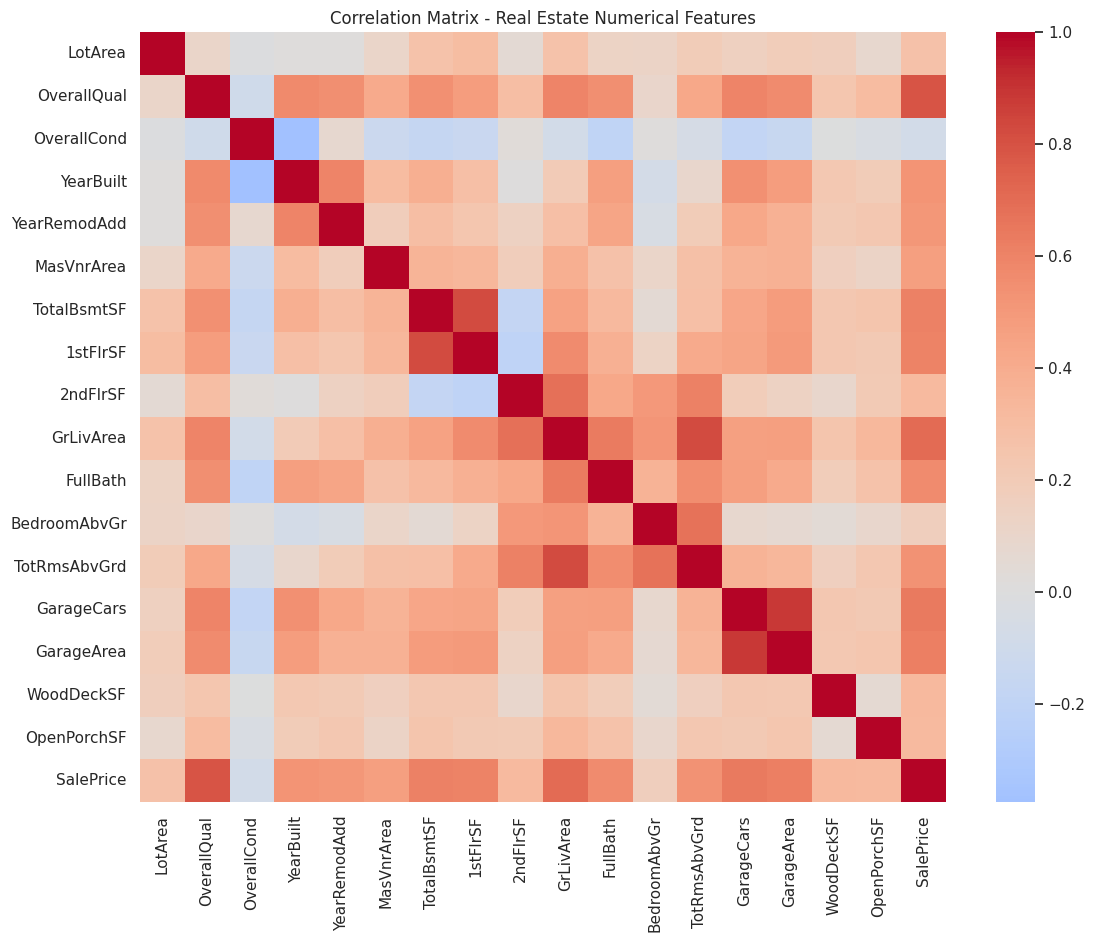

SalePrice: Skewness = 1.88, Kurtosis = 6.51
GrLivArea: Skewness = 1.37, Kurtosis = 4.87
LotArea: Skewness = 12.20, Kurtosis = 202.54
OverallQual: Skewness = 0.22, Kurtosis = 0.09
YearBuilt: Skewness = -0.61, Kurtosis = -0.44
GarageArea: Skewness = 0.18, Kurtosis = 0.91


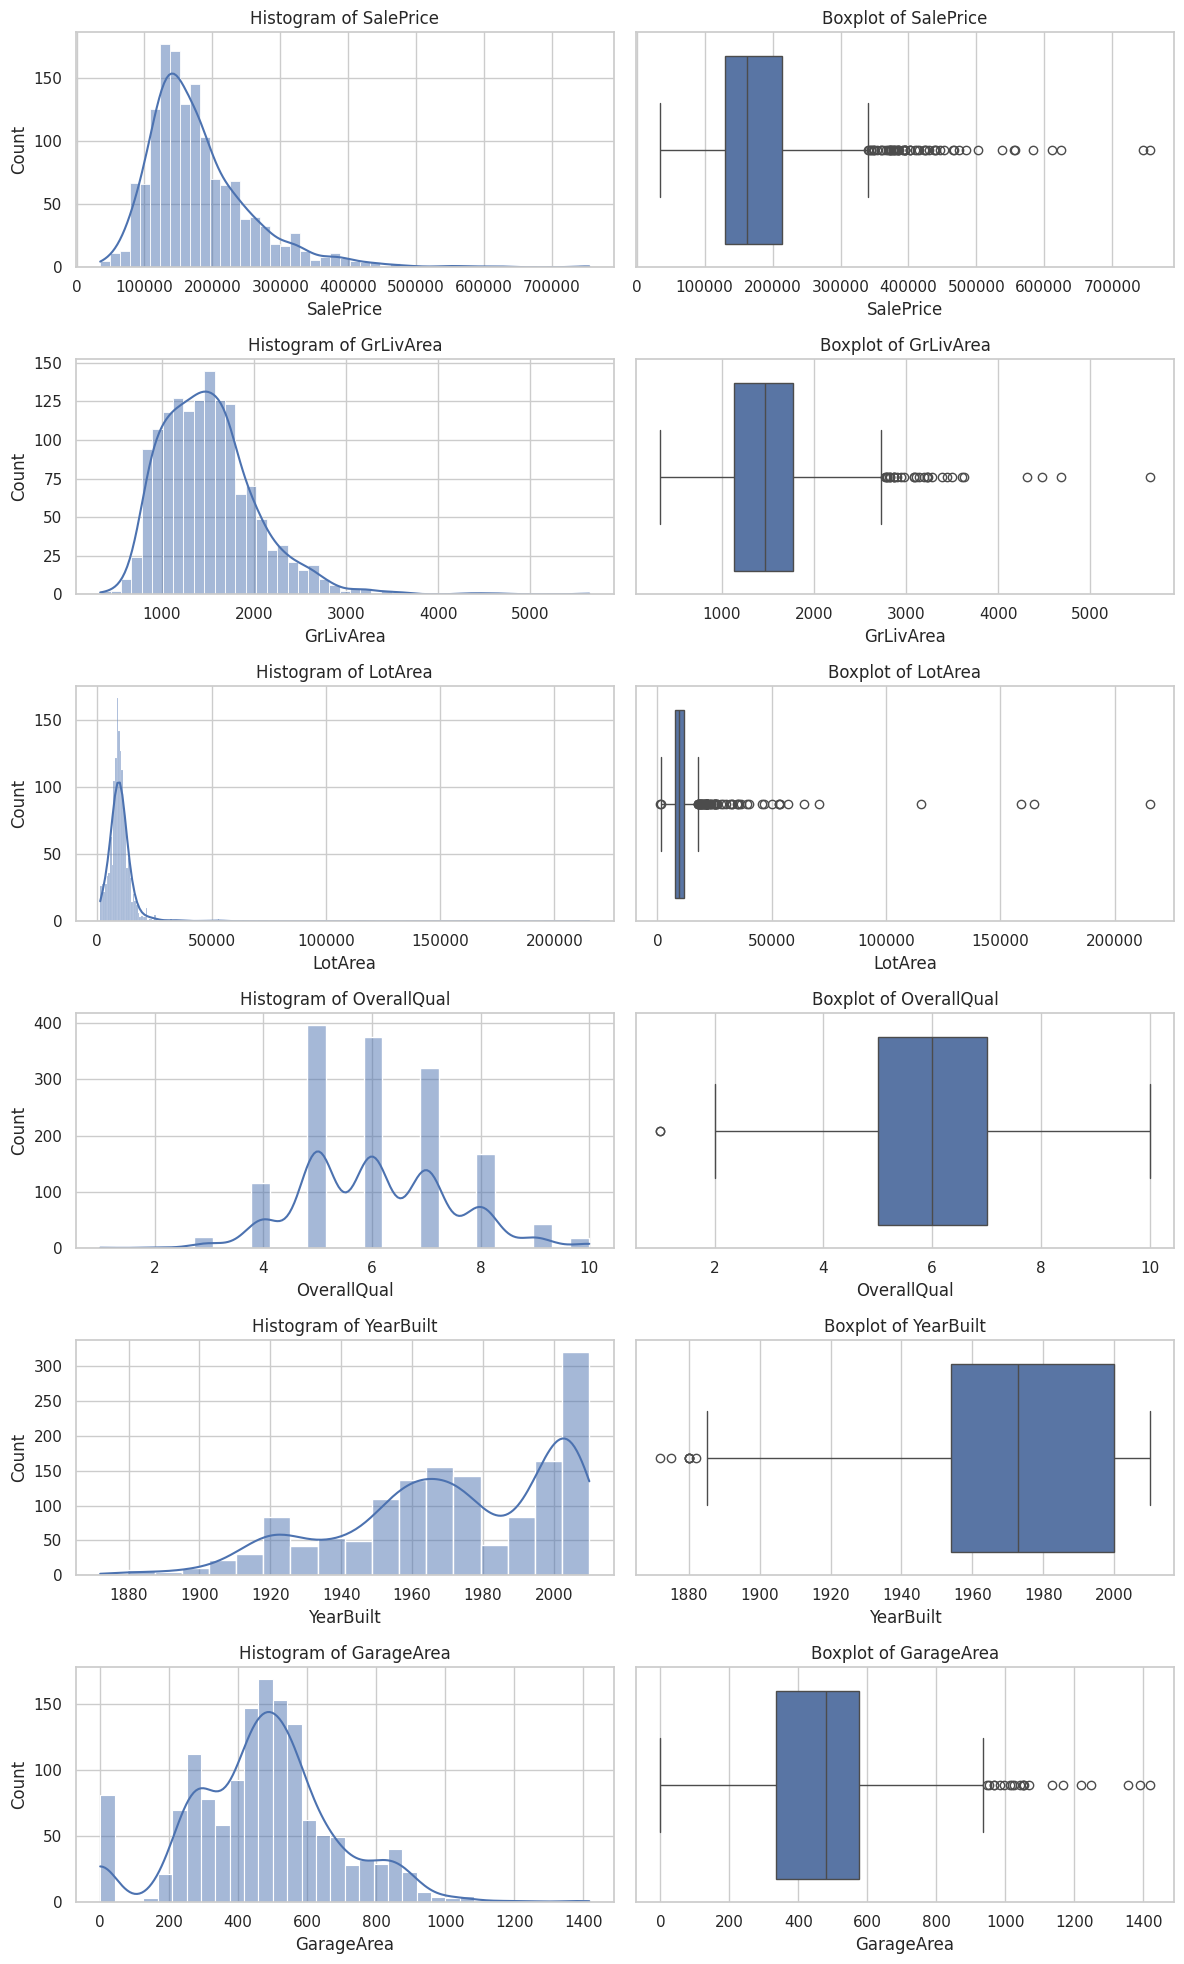

In [15]:
# --- 2. Exploratory Data Analysis ---

print("--- Structural Analysis ---")
print("Rows:", df.shape[0])
print("Numerical features:", df.shape[1])

print("\nStatistical Summary:")
display(df.describe().T[['mean', 'std', 'min', 'max']].round(2))

# Correlation matrix
plt.figure(figsize=(13, 10))
sns.heatmap(df.corr(), cmap='coolwarm', center=0)
plt.title("Correlation Matrix - Real Estate Numerical Features")
plt.show()

# Major features for distribution analysis
features_to_plot = [
    'SalePrice',
    'GrLivArea',
    'LotArea',
    'OverallQual',
    'YearBuilt',
    'GarageArea'
]

fig, axes = plt.subplots(
    len(features_to_plot),
    2,
    figsize=(12, 3.3 * len(features_to_plot))
)

for i, feature in enumerate(features_to_plot):

    sns.histplot(
        df[feature],
        kde=True,
        ax=axes[i, 0]
    )

    axes[i, 0].set_title(
        f'Histogram of {feature}'
    )

    sns.boxplot(
        x=df[feature],
        ax=axes[i, 1]
    )

    axes[i, 1].set_title(
        f'Boxplot of {feature}'
    )

    print(
        f"{feature}: "
        f"Skewness = {skew(df[feature]):.2f}, "
        f"Kurtosis = {kurtosis(df[feature]):.2f}"
    )

plt.tight_layout()
plt.show()

## EDA Discussion and Outlier Exploration

- **Correlation:** The correlation matrix shows substantial redundancy between several housing variables. SalePrice is strongly related to OverallQual, living area, garage capacity, and other measures of property size. GrLivArea is also naturally related to room counts and floor-area variables.

- **Distributions:** Several real-estate measurements are clearly non-Gaussian. LotArea, SalePrice, living area, and garage-related measurements contain right-skewed distributions and heavy tails.

- **Extreme Values:** Large values in housing data should not automatically be treated as errors. A property with an unusually large lot, living area, basement, or sale price may simply be a genuinely exceptional house.

- **Noise vs. Real Anomalies:** Some extreme observations may result from unusual sales or recording problems, but many represent legitimate luxury, oversized, old, or otherwise uncommon properties. Distinguishing these cases is one of the main challenges of anomaly detection.

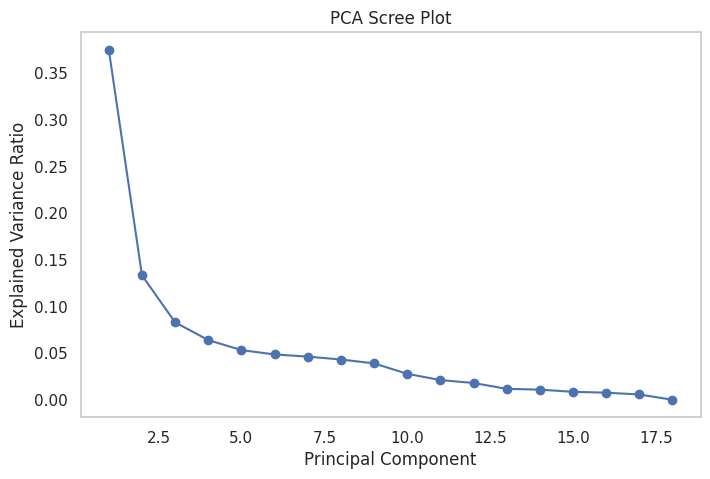

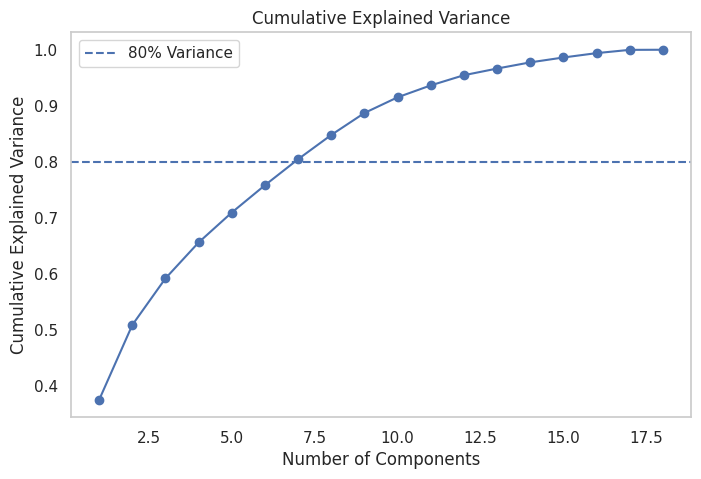

Components required for at least 80% variance: 7
Variance retained in 2D: 50.88%
Variance retained in 3D: 59.19%

Largest contributors to each component:

PC1


,Absolute Loading
SalePrice,0.342298
GrLivArea,0.317760
OverallQual,0.314303
GarageCars,0.291744
GarageArea,0.285356
FullBath,0.278748



PC2


,Absolute Loading
2ndFlrSF,0.490179
BedroomAbvGr,0.470494
TotRmsAbvGrd,0.387387
YearBuilt,0.297354
GrLivArea,0.293214
TotalBsmtSF,0.241490



PC3


,Absolute Loading
1stFlrSF,0.457863
LotArea,0.440150
YearRemodAdd,0.375881
TotalBsmtSF,0.369941
YearBuilt,0.341064
2ndFlrSF,0.288688


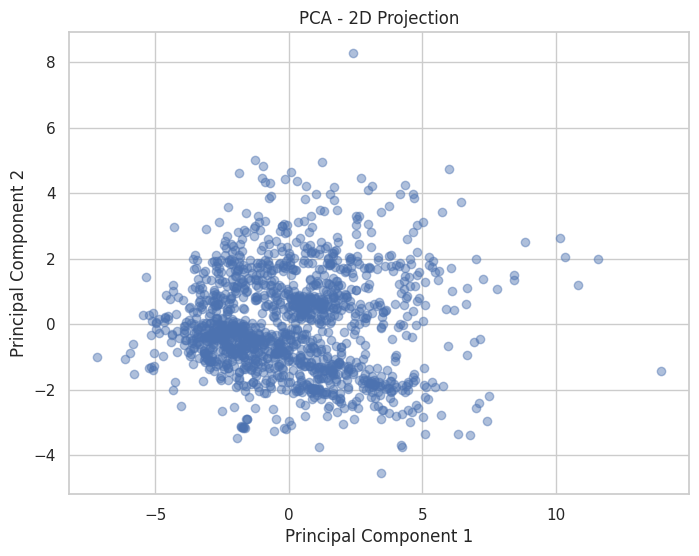

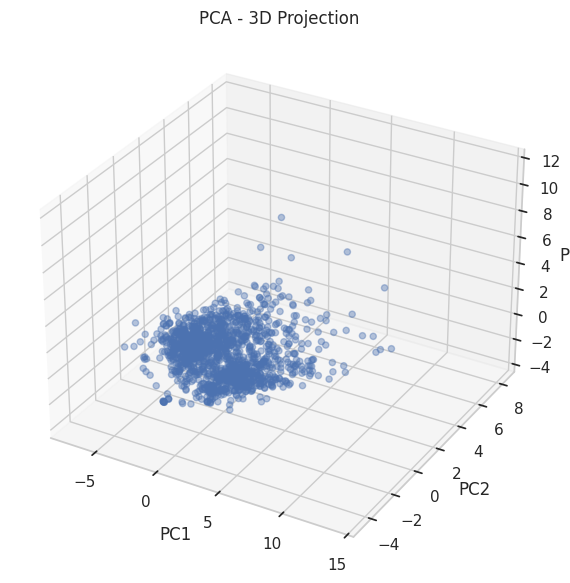

In [16]:
# --- 3. Dimensionality Reduction: PCA ---

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Scree Plot
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(explained_variance) + 1),
    explained_variance,
    marker='o'
)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Scree Plot')
plt.grid()
plt.show()

# Cumulative Explained Variance
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker='o'
)
plt.axhline(0.80, linestyle='--', label='80% Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')
plt.legend()
plt.grid()
plt.show()

components_80 = np.argmax(
    cumulative_variance >= 0.80
) + 1

print(
    "Components required for at least 80% variance:",
    components_80
)

print(
    f"Variance retained in 2D: "
    f"{cumulative_variance[1]:.2%}"
)

print(
    f"Variance retained in 3D: "
    f"{cumulative_variance[2]:.2%}"
)

# PCA loadings
loadings = pd.DataFrame(
    pca.components_[:3].T,
    index=df.columns,
    columns=['PC1', 'PC2', 'PC3']
)

print("\nLargest contributors to each component:")

for pc in loadings.columns:
    print(f"\n{pc}")
    display(
        loadings[pc]
        .abs()
        .sort_values(ascending=False)
        .head(6)
        .to_frame('Absolute Loading')
    )

# 2D Projection
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    alpha=0.45
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA - 2D Projection')
plt.show()

# 3D Projection
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    X_pca[:, 2],
    alpha=0.4
)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('PCA - 3D Projection')

plt.show()

## Dimensionality Reduction Discussion

- **Components Needed:** Approximately seven principal components are required to preserve at least 80% of the total variance. This indicates that the original 18-variable representation contains considerable redundancy, but cannot be reduced to only two dimensions without meaningful information loss.

- **PC1 – Property Size, Quality and Value:** The strongest contributions to PC1 come from SalePrice, GrLivArea, OverallQual, garage variables, and FullBath. PC1 can therefore be interpreted as a broad property-value and size dimension.

- **PC2 – House Layout:** PC2 is strongly influenced by second-floor area, bedrooms, number of rooms, and living area. It captures differences in internal layout and multi-story structure.

- **PC3 – Land and Ground-Floor Structure:** First-floor area, LotArea, basement area, remodeling year, and construction year contribute strongly to PC3.

- **Information Loss:** The first two components retain only about half of the total variance. Therefore, the 2D PCA plot is useful for visualization but should not be treated as a complete representation of the original high-dimensional data.

K-Means Silhouette Scores:


,Silhouette Score
2,0.232464
3,0.177964
4,0.173991
5,0.170522
6,0.143244


Selected number of clusters: 2


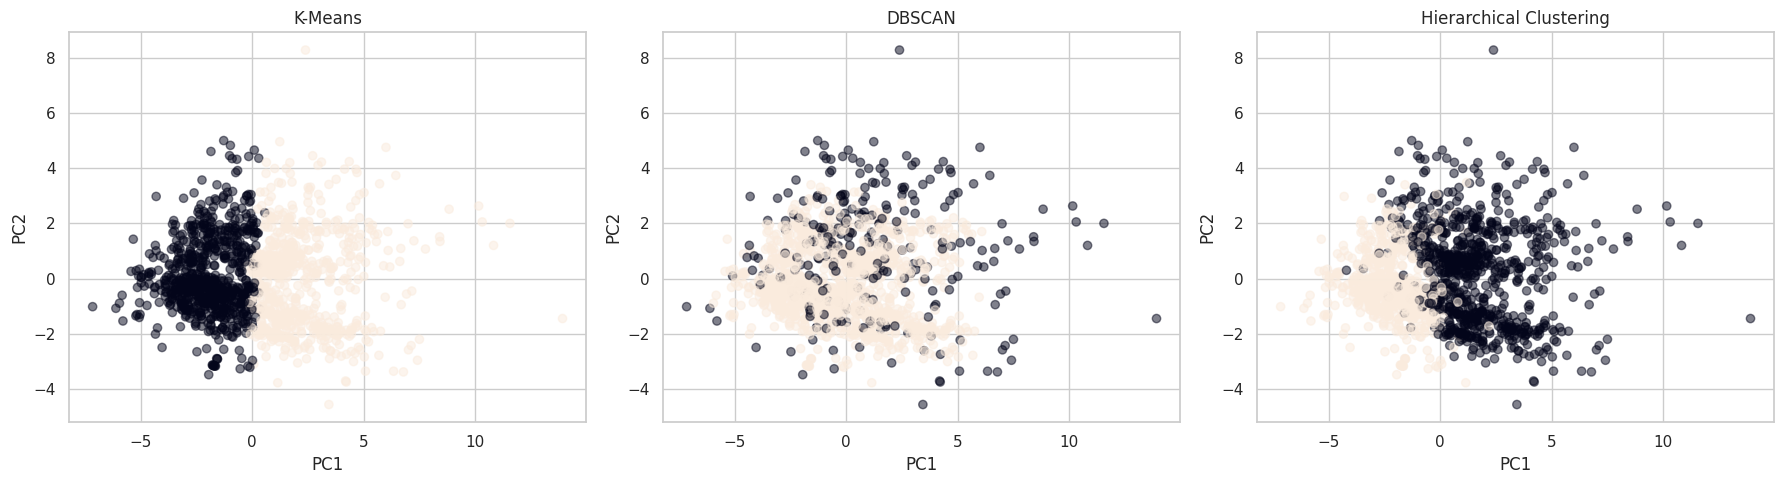

K-Means within/global variance ratio: 0.766
Hierarchical within/global variance ratio: 0.759


,SalePrice,OverallQual,GrLivArea,YearBuilt,GarageCars,LotArea
Cluster,,,,,,
0,131726.6,5.2,1215.2,1953.4,1.3,8885.0
1,237975.3,7.1,1863.7,1992.0,2.3,12409.4


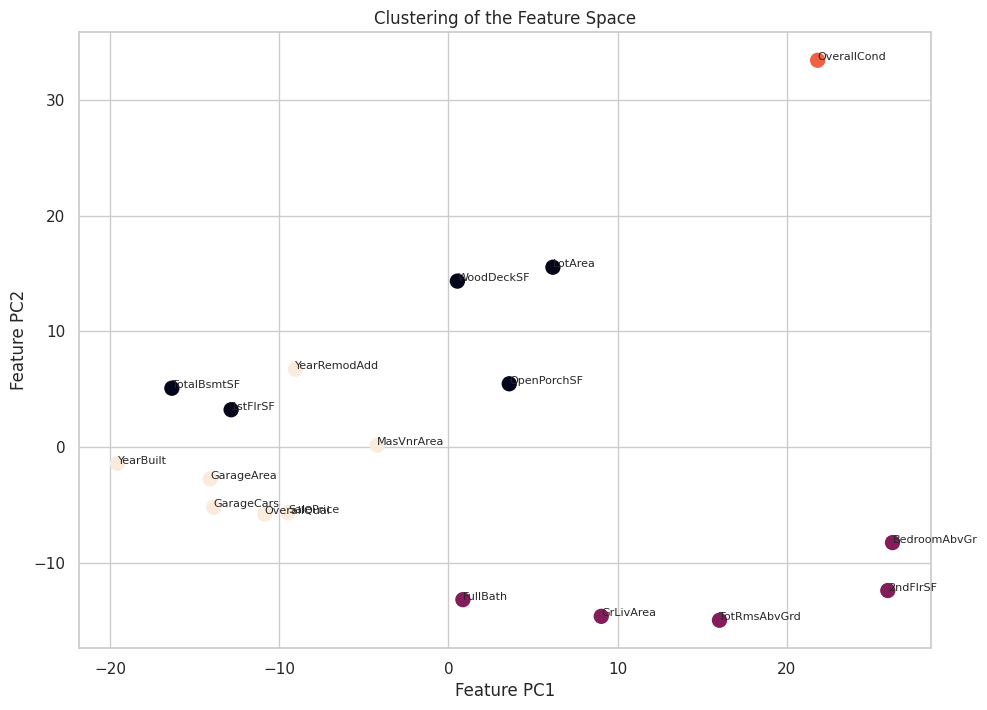

In [17]:
# --- 4. Clustering Analysis ---

# Select K for K-Means using Silhouette Score
silhouette_results = {}

for k in range(2, 7):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X_scaled)

    silhouette_results[k] = silhouette_score(
        X_scaled,
        labels
    )

print("K-Means Silhouette Scores:")
display(
    pd.Series(
        silhouette_results,
        name='Silhouette Score'
    ).to_frame()
)

best_k = max(
    silhouette_results,
    key=silhouette_results.get
)

print("Selected number of clusters:", best_k)

# 1. K-Means
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=20
)

labels_kmeans = kmeans.fit_predict(X_scaled)

# 2. DBSCAN
dbscan = DBSCAN(
    eps=2.5,
    min_samples=10
)

labels_dbscan = dbscan.fit_predict(X_scaled)

# 3. Hierarchical Clustering
hierarchical = AgglomerativeClustering(
    n_clusters=best_k
)

labels_hierarchical = hierarchical.fit_predict(
    X_scaled
)

# PCA visualization
fig, (ax1, ax2, ax3) = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

ax1.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels_kmeans,
    alpha=0.5
)
ax1.set_title('K-Means')

ax2.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels_dbscan,
    alpha=0.5
)
ax2.set_title('DBSCAN')

ax3.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels_hierarchical,
    alpha=0.5
)
ax3.set_title('Hierarchical Clustering')

for ax in (ax1, ax2, ax3):
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.tight_layout()
plt.show()


# Cluster variance compared with global variance
global_variance = np.var(
    X_scaled,
    axis=0
).mean()

def variance_ratio(X, labels):

    valid_labels = [
        label for label in np.unique(labels)
        if label != -1
    ]

    if len(valid_labels) == 0:
        return np.nan

    within_variances = [
        np.var(
            X[labels == label],
            axis=0
        ).mean()
        for label in valid_labels
    ]

    return np.mean(within_variances) / global_variance


print(
    "K-Means within/global variance ratio:",
    round(
        variance_ratio(
            X_scaled,
            labels_kmeans
        ),
        3
    )
)

print(
    "Hierarchical within/global variance ratio:",
    round(
        variance_ratio(
            X_scaled,
            labels_hierarchical
        ),
        3
    )
)


# Real-world K-Means cluster profiles
cluster_profiles = df.copy()
cluster_profiles['Cluster'] = labels_kmeans

display(
    cluster_profiles.groupby('Cluster')[
        [
            'SalePrice',
            'OverallQual',
            'GrLivArea',
            'YearBuilt',
            'GarageCars',
            'LotArea'
        ]
    ].mean().round(1)
)


# --- Clustering the Feature Space ---

X_features = X_scaled.T

feature_kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=20
)

feature_labels = feature_kmeans.fit_predict(
    X_features
)

feature_pca = PCA(n_components=2)

feature_projection = feature_pca.fit_transform(
    X_features
)

plt.figure(figsize=(11, 8))

plt.scatter(
    feature_projection[:, 0],
    feature_projection[:, 1],
    c=feature_labels,
    s=100
)

for i, feature in enumerate(df.columns):

    plt.annotate(
        feature,
        (
            feature_projection[i, 0],
            feature_projection[i, 1]
        ),
        fontsize=8
    )

plt.title(
    'Clustering of the Feature Space'
)
plt.xlabel('Feature PC1')
plt.ylabel('Feature PC2')
plt.show()

## Clustering Analysis Discussion

- **K-Means:** K-Means represents every cluster using a centroid and minimizes within-cluster squared distances. Using the Silhouette Score rather than selecting k arbitrarily gives a more defensible parameter choice. In this dataset, the strongest solution separates the housing market into broad property groups. One group contains lower-priced, smaller, and lower-quality houses, while the other contains larger, higher-quality, and more expensive properties.

- **DBSCAN:** DBSCAN identifies dense regions rather than forcing every property into a cluster. In this dataset, it tends to produce one dominant housing region while classifying less typical properties as noise. This illustrates its strong sensitivity to eps and min_samples when densities vary.

- **Hierarchical Clustering:** Hierarchical clustering produces a nested grouping structure and gives a broadly similar market separation to K-Means, although individual boundaries differ because it does not optimize the same centroid objective.

- **Variance Evaluation:** The within-cluster variance is lower than the global variance, indicating that the clustering produces internally more homogeneous groups. However, this metric favors compact clusters and is naturally more suitable for K-Means than for irregular density-based clusters such as DBSCAN.

- **Feature-Space Clustering:** Clustering the transposed matrix reveals related groups of features. Variables describing house size and room counts tend to behave similarly, while quality, age, value, and garage-related measures form other relationships. This analysis can reveal redundancy that is less obvious when clustering properties directly.

Different methods therefore produce different structures because they make different assumptions about geometry, density, and cluster shape.

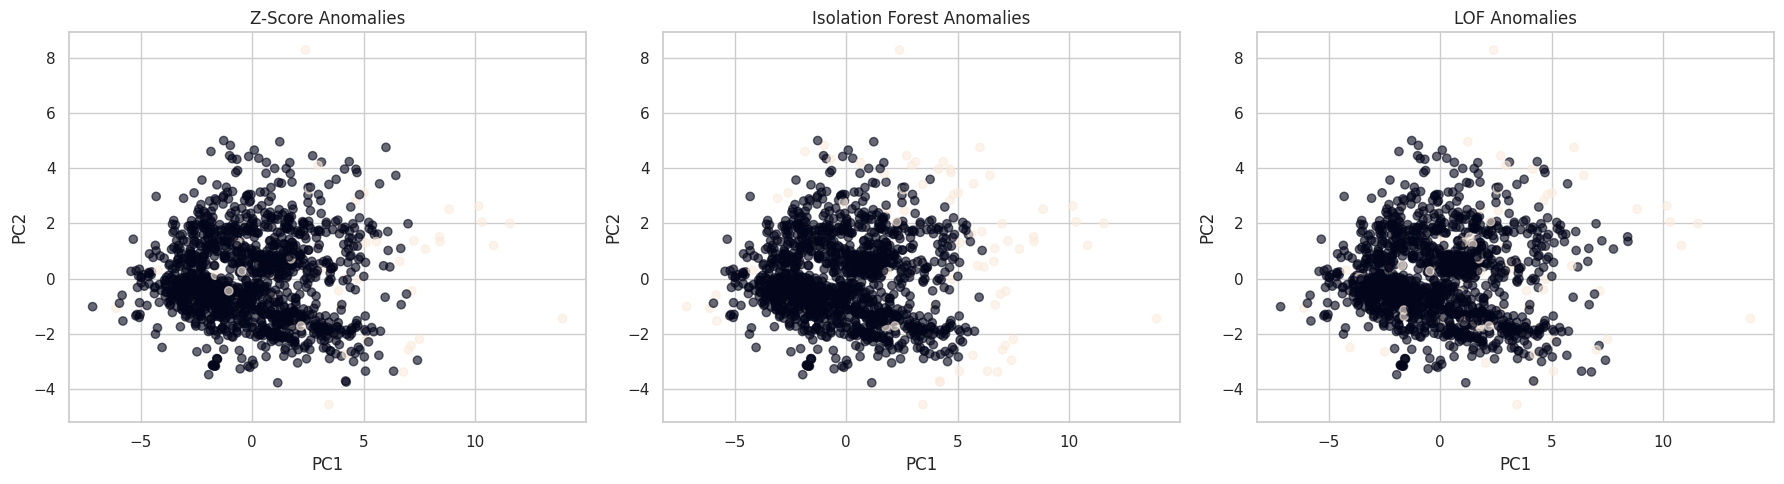

--- Number of Detected Anomalies ---
Z-Score             51
Isolation Forest    73
LOF                 73
dtype: int64

--- Agreement Between Methods ---
Z-Score & Isolation Forest: 30
Z-Score & LOF: 34
Isolation Forest & LOF: 36
Detected by all three: 22

--- Runtime (seconds) ---


,Runtime
Z-Score,0.000458
Isolation Forest,0.597201
LOF,0.033896


,SalePrice,GrLivArea,LotArea,OverallQual,YearBuilt,GarageArea,MethodsFlagged,IsolationScore
523,184750,4676,40094,10,2007,884,3,0.687875
691,755000,4316,21535,10,1994,832,3,0.673101
1298,160000,5642,63887,10,2008,1418,3,0.670537
1169,625000,3627,35760,10,1995,807,3,0.654564
769,538000,3279,53504,8,2003,841,3,0.633630
53,385000,1842,50271,9,1981,894,3,0.632994
1182,745000,4476,15623,10,1996,813,3,0.626000
583,325000,2775,13500,10,1893,880,3,0.619799
635,200000,3395,10896,6,1914,0,3,0.619768
1328,256000,2792,10440,6,1920,520,3,0.592790


In [18]:
# --- 5. Multi-Dimensional Anomaly Detection ---

runtime = {}

# 1. Z-Score
start = time.time()

z_scores = np.abs(X_scaled)

z_outliers = (
    z_scores > 4
).any(axis=1)

runtime['Z-Score'] = time.time() - start


# 2. Isolation Forest
start = time.time()

isolation_forest = IsolationForest(
    contamination=0.05,
    random_state=42
)

isolation_predictions = (
    isolation_forest.fit_predict(X_scaled)
)

isolation_outliers = (
    isolation_predictions == -1
)

isolation_score = -isolation_forest.score_samples(
    X_scaled
)

runtime['Isolation Forest'] = (
    time.time() - start
)


# 3. Local Outlier Factor
start = time.time()

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.05
)

lof_predictions = lof.fit_predict(
    X_scaled
)

lof_outliers = (
    lof_predictions == -1
)

runtime['LOF'] = time.time() - start


# Visualize anomalies in PCA space
fig, (ax1, ax2, ax3) = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

ax1.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=z_outliers,
    alpha=0.6
)

ax1.set_title(
    'Z-Score Anomalies'
)

ax2.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=isolation_outliers,
    alpha=0.6
)

ax2.set_title(
    'Isolation Forest Anomalies'
)

ax3.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=lof_outliers,
    alpha=0.6
)

ax3.set_title(
    'LOF Anomalies'
)

for ax in (ax1, ax2, ax3):
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.tight_layout()
plt.show()


# Method comparison
comparison = pd.DataFrame({
    'Z-Score': z_outliers,
    'Isolation Forest': isolation_outliers,
    'LOF': lof_outliers
})

print("--- Number of Detected Anomalies ---")
print(comparison.sum())

print("\n--- Agreement Between Methods ---")

print(
    "Z-Score & Isolation Forest:",
    (z_outliers & isolation_outliers).sum()
)

print(
    "Z-Score & LOF:",
    (z_outliers & lof_outliers).sum()
)

print(
    "Isolation Forest & LOF:",
    (isolation_outliers & lof_outliers).sum()
)

print(
    "Detected by all three:",
    (
        z_outliers
        & isolation_outliers
        & lof_outliers
    ).sum()
)

print("\n--- Runtime (seconds) ---")

display(
    pd.Series(
        runtime,
        name='Runtime'
    ).to_frame()
)


# Examine strongest shared anomalies
anomaly_review = df_raw[
    [
        'SalePrice',
        'GrLivArea',
        'LotArea',
        'OverallQual',
        'YearBuilt',
        'GarageArea'
    ]
].copy()

anomaly_review['MethodsFlagged'] = (
    z_outliers.astype(int)
    + isolation_outliers.astype(int)
    + lof_outliers.astype(int)
)

anomaly_review['IsolationScore'] = (
    isolation_score
)

display(
    anomaly_review
    .sort_values(
        ['MethodsFlagged', 'IsolationScore'],
        ascending=False
    )
    .head(12)
)

# 5. Multi-Dimensional Anomaly Detection & Method Comparison

### Z-Score

Z-Score detects properties containing at least one extremely standardized feature value. Its main limitation is the assumption that extreme standardized deviations are meaningful. This is problematic for variables such as LotArea and SalePrice, which are strongly skewed rather than Gaussian.

In high dimensions, checking many variables also increases the probability that an otherwise legitimate observation appears extreme in at least one feature.

### Isolation Forest

Isolation Forest detects unusual observations by repeatedly applying random feature and split-value partitions. Rare properties generally require fewer random partitions to become isolated and therefore receive stronger anomaly scores.

The contamination parameter was set to 5%, meaning that the algorithm is instructed to treat approximately 5% of the housing observations as anomalies. A larger anomaly score in our implementation represents a more easily isolated and unusual property.

Its main advantage is that it does not require Gaussian distributions and avoids relying entirely on pairwise distances.

### Local Outlier Factor

LOF detects local anomalies by comparing the density around a property with the density around its nearest neighbors. This allows it to identify a house that is unusual relative to otherwise similar houses, even when it is not globally extreme.

Its main limitation is sensitivity to the neighborhood size k and to distance calculations in high-dimensional spaces.

### Comparison

The three methods identify overlapping but non-identical sets of houses. Properties detected by all three methods are particularly interesting because they are extreme from statistical, isolation-based, and local-density perspectives.

Method-specific anomalies are also meaningful. A very large luxury property may be globally extreme and easily detected by Z-Score and Isolation Forest, while LOF may consider it less unusual if similar luxury properties exist nearby in feature space.

All methods were applied after StandardScaler because distance and magnitude differences between variables such as SalePrice, OverallQual, and LotArea would otherwise distort the analysis.

Runtime results also illustrate scalability differences: Z-Score is extremely simple, Isolation Forest scales efficiently, while LOF requires neighborhood-distance calculations.

Because this dataset contains no ground-truth anomaly labels, exact False Positives and False Negatives cannot be measured. In real-estate terms, a False Positive would mean labeling a legitimate but unusual property as suspicious, while a False Negative would mean failing to detect an actual data error or genuinely exceptional sale.


# 6. Critical Analysis and Reflection

- **Why anomaly detection is difficult:** There is no universal mathematical definition of an abnormal house. A $700,000 property may be an anomaly statistically while still being a completely legitimate luxury home.

- **Curse of dimensionality:** As dimensionality increases, observations become sparse and Euclidean distances become less discriminative. This affects methods such as LOF and distance-based clustering.

- **Noise vs. Genuine Anomaly:** An extreme LotArea may represent a data-entry error, but it may also describe a legitimate property with unusually large land. Domain context is therefore necessary before removing an observation.

- **Gaussian Assumption:** Real-estate variables such as price and lot size are skewed and heavy-tailed. Gaussian assumptions may incorrectly flag legitimate luxury properties or fail to identify unusual multidimensional combinations.

- **PCA Limitation:** The 2D PCA visualization retains only part of the total variance. Two properties that appear close in the plot may still be very different in dimensions discarded by the projection. Therefore, PCA visualizations must not be treated as ground truth.

### Ethical Considerations

Anomaly detection can create harmful consequences when its output is treated as an objective label. In real estate, automatically labeling properties or transactions as abnormal could unfairly affect sellers, buyers, neighborhoods, or financial decisions.

The same issue is more serious in sensitive domains. In medicine, a false alarm can cause unnecessary testing while a missed anomaly can delay treatment. In cybersecurity, excessive false positives create alert fatigue, but missing a real anomaly may allow an attack. In surveillance systems, biased data can cause minority groups or uncommon behaviors to be disproportionately labeled as abnormal.

Anomaly-detection systems should therefore be used as decision-support tools rather than unquestioned final decision makers.

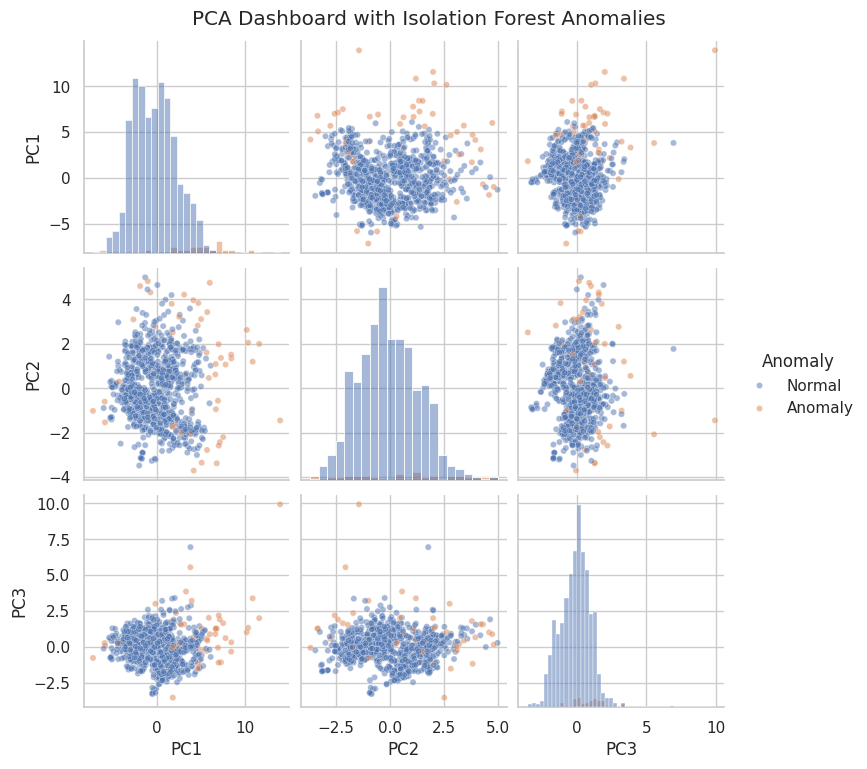

In [19]:
# --- 7. Final Visualization Dashboard - Bonus ---

import plotly.express as px

dashboard = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'PC3': X_pca[:, 2],
    'SalePrice': df['SalePrice'].values,
    'Cluster': labels_kmeans.astype(str),
    'Anomaly': np.where(
        isolation_outliers,
        'Anomaly',
        'Normal'
    )
})

# Interactive PCA anomaly exploration
fig = px.scatter(
    dashboard,
    x='PC1',
    y='PC2',
    color='Anomaly',
    hover_data=[
        'SalePrice',
        'Cluster',
        'PC3'
    ],
    title='Interactive PCA Anomaly Exploration'
)

fig.show()

# Compact pairplot
dashboard_sample = dashboard.sample(
    n=min(1000, len(dashboard)),
    random_state=42
)

sns.pairplot(
    dashboard_sample[
        ['PC1', 'PC2', 'PC3', 'Anomaly']
    ],
    hue='Anomaly',
    diag_kind='hist',
    plot_kws={
        'alpha': 0.5,
        's': 20
    }
)

plt.suptitle(
    'PCA Dashboard with Isolation Forest Anomalies',
    y=1.02
)

plt.show()